In [1]:
%matplotlib widget

In [2]:
import logging
import os
import pickle
import random

import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

from xasml import resource_path
from xasml.datasets.fdmnes import FE_REFERENCE_MBARN
from xasml.models.data import Processor
from xasml.models.io import read_from_h5
from xasml.models.metrics import calculate_accuracies, display_metrics

In [3]:
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
logging.getLogger("xasml").setLevel(logging.DEBUG)
logger = logging.getLogger("xasml.random_forest_classifier")

plt.style.use("stylelib/presentation.mplstyle")

In [4]:
# Define some constants.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

ELEMENT = "Fe"
JOB = "job15"
RESOURCE = "xasml:datasets/fdmnes/materials.h5"
ENERGY_SHIFT = 7112
ENERGY_MIN = -10 + ENERGY_SHIFT
ENERGY_MAX = 60 + ENERGY_SHIFT
LABELS = ["O:6", "T:4"]
NORMALIZATION = "area"  # Z-score fails when adding noise.
OUTLIER_THRESHOLD = 4
PREFIX = os.path.join("figures", "random_forest_classifier")
EXTENSION = "pdf"
DPI = 300

# Read data from file.
X, y, metas = read_from_h5(resource_path(RESOURCE), ELEMENT, JOB)

# Create a processor object.
processor = Processor(X, y, metas=metas)

In [5]:
processor.reset()
processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

energies = np.copy(processor.metas[0]["energies"]) + ENERGY_SHIFT
mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
energies = energies[mask]
processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
processor.normalize(method=NORMALIZATION, reference=energies)
processor.split(test_size=0.20, random_seed=RANDOM_SEED)

mask_o6 = processor.y == "O:6"
mask_t4 = processor.y == "T:4"


2026-08-17 22:25:33,413 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:25:33,414 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:25:36,295 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:25:36,296 - xasml.models.data - DEBUG - Number of occurrences for each label:


2026-08-17 22:25:36,296 - xasml.models.data - DEBUG - O:6: 2027


...

2026-08-17 22:25:39,756 - xasml.models.data - DEBUG - y_train: (2187,)


2026-08-17 22:25:39,756 - xasml.models.data - DEBUG - metas_train: 2187


2026-08-17 22:25:39,756 - xasml.models.data - DEBUG - X_test: (547, 701)


2026-08-17 22:25:39,757 - xasml.models.data - DEBUG - y_test: (547,)


2026-08-17 22:25:39,757 - xasml.models.data - DEBUG - metas_test: 547


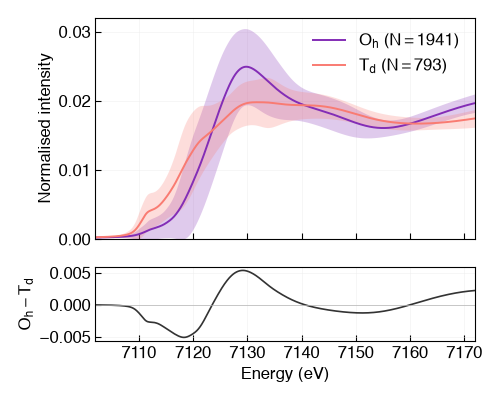

In [6]:
# Colours drawn from the Petroff10 colour-blind-safe palette
# (Petroff, arXiv:2107.02270; included in matplotlib >= 3.10).
OH_COLOR = "#832db6"
TD_COLOR = "#f97b72"

fig, (ax, ax_diff) = plt.subplots(
    2,
    1,
    figsize=(5, 4),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

mean_by_class = {}
for mask, color, label, key in [
    (mask_o6, OH_COLOR, rf"$O_h$ ($N={mask_o6.sum()}$)", "o6"),
    (mask_t4, TD_COLOR, rf"$T_d$ ($N={mask_t4.sum()}$)", "t4"),
]:
    spectra = processor.X[mask, :]
    mean = spectra.mean(axis=0)
    std = spectra.std(axis=0)
    ax.plot(energies, mean, lw=1.4, color=color, label=label)
    ax.fill_between(energies, mean - std, mean + std, color=color, alpha=0.25, lw=0)
    mean_by_class[key] = mean

ax_diff.plot(energies, mean_by_class["o6"] - mean_by_class["t4"], lw=1.2, color="0.2")
ax_diff.axhline(0, color="0.7", lw=0.5)

for a in (ax, ax_diff):
    a.grid(True, color="0.92", linewidth=0.6, zorder=0)
    a.set_axisbelow(True)
    a.tick_params(direction="in", length=4, top=False, right=False)
    a.set_xlim(energies[0], energies[-1])

ax.set_ylim(bottom=0)
ax.set_ylabel("Normalised intensity")
ax.legend(loc="upper right", frameon=False)
ax_diff.set_ylabel(r"$O_h - T_d$")
ax_diff.set_xlabel("Energy (eV)")

fig.tight_layout()
fig.savefig(f"{PREFIX}_spectra.{EXTENSION}", dpi=DPI, bbox_inches="tight")

## Classifier

2026-08-17 22:25:41,977 - xasml.models.metrics - DEBUG - Evaluating predictions on 547 samples across 2 classes.


2026-08-17 22:25:41,981 - xasml.models.metrics - INFO - Balanced accuracy: 92.3%


2026-08-17 22:25:41,982 - xasml.models.metrics - INFO -   O:6: 96.6%


2026-08-17 22:25:41,982 - xasml.models.metrics - INFO -   T:4: 88.1%


2026-08-17 22:25:41,984 - xasml.models.metrics - INFO - Accuracy: 94.1%


2026-08-17 22:25:41,984 - xasml.models.metrics - INFO - F1 score: 94.1%


2026-08-17 22:25:42,049 - xasml.models.metrics - DEBUG - Confusion matrix saved to figures/random_forest_classifier_cm.pdf.


Mean CV Score: 0.915
Standard Deviation: 0.008


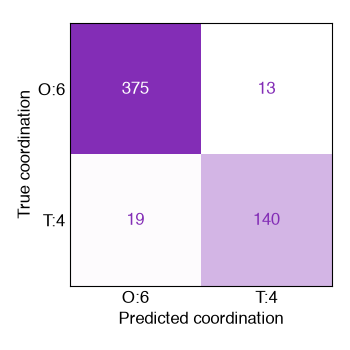

In [7]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_SEED,
    class_weight="balanced",
)

model.fit(processor.X_train, processor.y_train)
y_pred = model.predict(processor.X_test)
display_metrics(
    processor.y_test,
    y_pred,
    display_labels=LABELS,
    cm_name=f"{PREFIX}_cm.{EXTENSION}",
    dpi=DPI,
)

with open(f"{PREFIX}_model.pkl", "wb") as f:
    pickle.dump(model, f)

cv = StratifiedKFold(n_splits=5)
cv_scores = cross_val_score(
    model, processor.X, processor.y, cv=cv, scoring="balanced_accuracy"
)
print(f"Mean CV Score: {cv_scores.mean():.3f}")
print(f"Standard Deviation: {cv_scores.std():.3f}")

## Shift

2026-08-17 22:25:50,915 - xasml.random_forest_classifier - INFO - Evaluating shift: -1.0 eV


2026-08-17 22:25:50,918 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:25:50,919 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:25:54,099 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:25:54,100 - xasml.models.data - DEBUG - Number of occurrences for each label:


...

2026-08-17 22:26:22,799 - xasml.models.metrics - INFO -   T:4: 82.4%


2026-08-17 22:26:22,801 - xasml.models.metrics - INFO - Accuracy: 92.3%


2026-08-17 22:26:22,801 - xasml.models.metrics - INFO - F1 score: 92.2%


2026-08-17 22:26:22,861 - xasml.models.metrics - DEBUG - Confusion matrix saved to figures/random_forest_classifier_shift_+1.0eV_cm.pdf.


  Shift (eV)       O:6       T:4    Balanced
--------------------------------------------
        -1.0    96.4%    83.6%      90.0%
        -0.5    97.2%    88.7%      92.9%
         0.0    96.6%    88.1%      92.3%
         0.5    96.4%    86.8%      91.6%
         1.0    96.4%    82.4%      89.4%


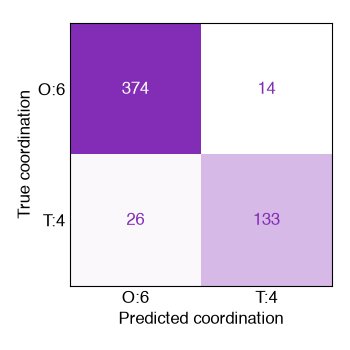

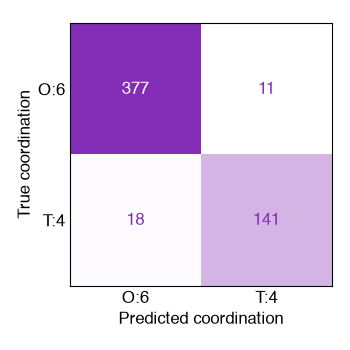

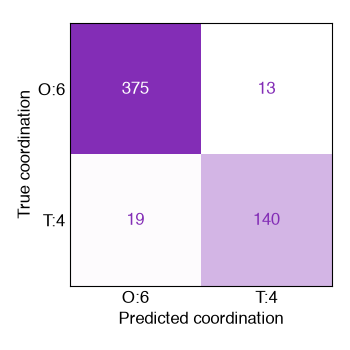

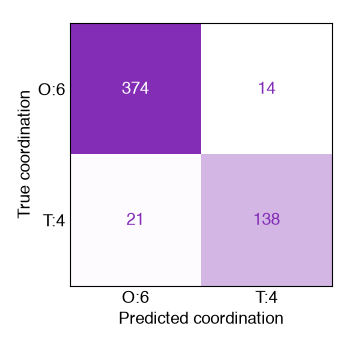

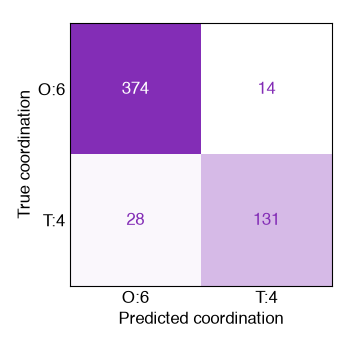

In [8]:
SHIFTS = [-1.0, -0.5, 0.0, 0.5, 1.0]
shift_results = []
for shift in SHIFTS:
    logger.info(f"Evaluating shift: {shift} eV")

    # Reset all data and split it again as the shift will affect it.
    processor.reset()
    processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

    energies = processor.metas[0]["energies"] + ENERGY_SHIFT
    processor.shift(shift, reference=energies)
    mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
    energies = energies[mask]
    processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
    processor.normalize(method=NORMALIZATION, reference=energies)
    processor.split(test_size=0.20, random_seed=RANDOM_SEED)

    y_pred = model.predict(processor.X_test)
    accuracies = display_metrics(
        processor.y_test,
        y_pred,
        display_labels=LABELS,
        cm_name=f"{PREFIX}_shift_{shift:+.1f}eV_cm.{EXTENSION}",
        dpi=DPI,
    )
    shift_results.append((shift, accuracies))

# Summary table.
header = (
    f"{'Shift (eV)':>12}"
    + "".join(f"{cls:>10}" for cls in LABELS)
    + f"{'Balanced':>12}"
)
print(header)
print("-" * len(header))
for shift, accs in shift_results:
    row = (
        f"{shift:>12}"
        + "".join(f"{accs[cls]:>9.1%}" for cls in LABELS)
        + f"{accs['balanced']:>11.1%}"
    )
    print(row)

## Noise

2026-08-17 22:26:22,959 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:26:22,960 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:26:26,688 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:26:26,689 - xasml.models.data - DEBUG - Number of occurrences for each label:


2026-08-17 22:26:26,689 - xasml.models.data - DEBUG - O:6: 2027


...

2026-08-17 22:44:04,846 - xasml.models.data - INFO - Added Poisson noise to the 'test' subset using an SNR of 250 at a reference intensity of 0.037.


2026-08-17 22:44:04,856 - xasml.models.metrics - INFO - Balanced accuracy: 92.6%


2026-08-17 22:44:04,857 - xasml.models.metrics - INFO -   O:6: 97.2%


2026-08-17 22:44:04,857 - xasml.models.metrics - INFO -   T:4: 88.1%


         SNR       O:6       T:4    Balanced
--------------------------------------------
          10    99.5%    17.0%      58.2%
          25    97.9%    74.8%      86.4%
          50    97.7%    84.3%      91.0%
         100    97.7%    87.4%      92.6%
         250    97.2%    88.1%      92.6%


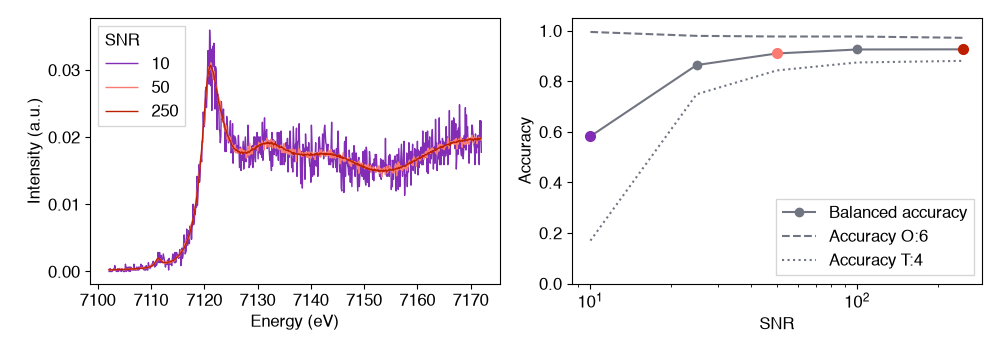

In [9]:
ID_TO_PLOT = 13
SNRS = [10, 25, 50, 100, 250]
SELECTED_SNRS = [10, 50, 250]
# Reuse the violet and rose from the class plot; add Petroff10 red as the third.
SNR_COLORS = ["#832db6", "#f97b72", "#bd1f01"]
ACCURACY_COLOR = "#717581"

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax1, ax2 = ax

noise_results = []
accuracies = []
color_index = 0
for snr in SNRS:
    processor.reset()
    processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

    energies = processor.metas[0]["energies"] + ENERGY_SHIFT
    mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
    energies = energies[mask]
    processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
    processor.split(test_size=0.20, random_seed=RANDOM_SEED)

    processor.add_poisson_noise(
        snr=snr,
        reference_intensity=FE_REFERENCE_MBARN,
        normalization=NORMALIZATION,
        reference=energies,
        subset="test",
        random_seed=RANDOM_SEED,
    )

    if snr in SELECTED_SNRS:
        data = processor.X_test.transpose()[:, ID_TO_PLOT]
        ax1.plot(energies, data, lw=1, color=SNR_COLORS[color_index], label=f"{snr}")
        color_index += 1
    y_pred = model.predict(processor.X_test)
    accs = calculate_accuracies(processor.y_test, y_pred)
    balanced_accuracy = accs["balanced"]
    accuracies.append(balanced_accuracy)
    noise_results.append((snr, accs))

ax1.legend(title="SNR", alignment="left")
ax1.set_xlabel("Energy (eV)")
ax1.set_ylabel("Intensity (a.u.)")

# Plot balanced accuracy as solid line with colored markers for selected SNRs.
ax2.plot(
    SNRS,
    accuracies,
    marker="o",
    ls="-",
    color=ACCURACY_COLOR,
    label="Balanced accuracy",
)

for i, snr in enumerate(SELECTED_SNRS):
    ax2.plot(snr, accuracies[SNRS.index(snr)], marker="o", ms=7, color=SNR_COLORS[i])

# Plot per-class accuracies with distinct line styles.
o6_accs = [accs["O:6"] for _, accs in noise_results]
t4_accs = [accs["T:4"] for _, accs in noise_results]
ax2.plot(SNRS, o6_accs, ls="--", color=ACCURACY_COLOR, label="Accuracy O:6")
ax2.plot(SNRS, t4_accs, ls=":", color=ACCURACY_COLOR, label="Accuracy T:4")

ax2.set_xscale("log")
ax2.set_xlabel("SNR")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.0, 1.05)
ax2.legend()
fig.tight_layout()
fig.savefig(f"{PREFIX}_poisson_noise.{EXTENSION}", dpi=DPI)

# Summary table.
header = f"{'SNR':>12}" + "".join(f"{cls:>10}" for cls in LABELS) + f"{'Balanced':>12}"
print(header)
print("-" * len(header))
for snr, accs in noise_results:
    row = (
        f"{snr:>12}"
        + "".join(f"{accs[cls]:>9.1%}" for cls in LABELS)
        + f"{accs['balanced']:>11.1%}"
    )
    print(row)

## Self-absorption

2026-08-17 22:44:05,075 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:44:05,075 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:44:08,703 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:44:08,703 - xasml.models.data - DEBUG - Number of occurrences for each label:


2026-08-17 22:44:08,704 - xasml.models.data - DEBUG - O:6: 2027


...

2026-08-17 22:44:12,538 - xasml.models.metrics - INFO -   T:4: 89.9%


2026-08-17 22:44:12,540 - xasml.models.metrics - INFO - Accuracy: 87.6%


2026-08-17 22:44:12,540 - xasml.models.metrics - INFO - F1 score: 87.9%


2026-08-17 22:44:12,602 - xasml.models.metrics - DEBUG - Confusion matrix saved to figures/random_forest_classifier_with_incident_beam_self_absorption_cm.pdf.


{'accuracy': 0.8756855575868373,
 'balanced': 0.8826752253128445,
 np.str_('O:6'): 0.865979381443299,
 np.str_('T:4'): 0.89937106918239}

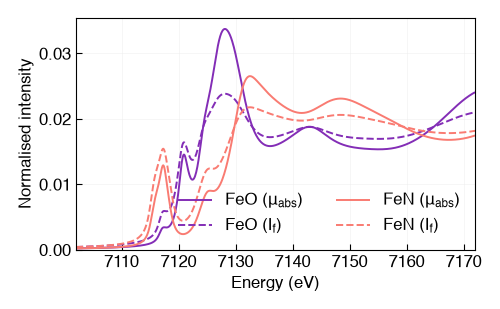

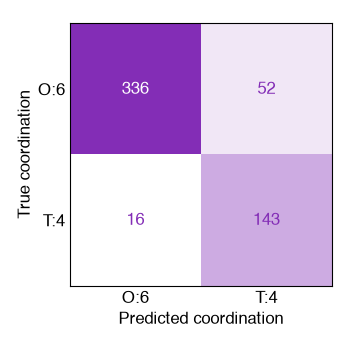

In [10]:
from xasml.models.fluorescence import calculate_spectrum

# Match the Petroff10 colours used for the class-mean spectra in Figure 1.
OH_COLOR = "#832db6"
TD_COLOR = "#f97b72"
COORD_COLORS = {"O:6": OH_COLOR, "T:4": TD_COLOR}

fig, ax = plt.subplots(figsize=(5, 3.09))

processor.reset()
processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

energies = np.copy(processor.metas[0]["energies"]) + ENERGY_SHIFT
mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
energies = energies[mask]
processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
processor.split(test_size=0.20, random_seed=RANDOM_SEED)

# Find one O:6 (FeO) and one T:4 (FeN) by formula in the full processed data.
TARGETS = [("FeO", "O:6"), ("FeN", "T:4")]

SA_KWARGS = dict(
    binder="boron nitride",
    phi=45,
    theta=45,
    absorbing_element=ELEMENT,
    compound_weight_fraction=0.1,
    thickness=0.1,
)

for formula, coordination in TARGETS:
    idx = next(
        i
        for i, (meta, label) in enumerate(zip(processor.metas, processor.y))
        if meta["structure"].composition.reduced_formula == formula
        and label == coordination
    )
    spectrum_clean = processor.X[idx]
    spectrum_fluor = calculate_spectrum(
        energies=energies,
        intensity=spectrum_clean,
        compound=processor.metas[idx]["structure"],
        **SA_KWARGS,  # type: ignore
    )
    spectrum_clean = spectrum_clean / np.trapezoid(spectrum_clean, energies)
    # Normalize the fluorescence spectrum.
    spectrum_fluor = spectrum_fluor / np.trapezoid(spectrum_fluor, energies)
    color = COORD_COLORS[coordination]
    ax.plot(
        energies,
        spectrum_clean,
        lw=1.4,
        color=color,
        label=rf"{formula} ($\mu_{{\mathrm{{abs}}}}$)",
    )
    ax.plot(
        energies,
        spectrum_fluor,
        lw=1.4,
        ls="--",
        color=color,
        label=rf"{formula} ($I_f$)",
    )

ax.grid(True, color="0.92", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(direction="in", length=4, top=False, right=False)
ax.set_xlim(energies[0], energies[-1])
ax.set_ylim(bottom=0)
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("Normalised intensity")
ax.legend(loc="lower right", ncol=2, frameon=False)

fig.tight_layout()
fig.savefig(f"{PREFIX}_with_incident_beam_self_absorption.{EXTENSION}", dpi=DPI)

# Apply self-absorption to all test spectra and predict on the distorted set.
X_test_sa = np.array([
    calculate_spectrum(
        energies=energies,
        intensity=spectrum,
        compound=meta["structure"],
        **SA_KWARGS,  # type: ignore
    )
    for spectrum, meta in zip(processor.X_test, processor.metas_test)
])
# Re-normalize each self-absorbed spectrum.
X_test_sa = X_test_sa / np.trapezoid(X_test_sa, energies, axis=1)[:, np.newaxis]

y_pred = model.predict(X_test_sa)
display_metrics(
    processor.y_test,
    y_pred,
    display_labels=LABELS,
    cm_name=f"{PREFIX}_with_incident_beam_self_absorption_cm.{EXTENSION}",
    dpi=DPI,
)
